# Part 2 (Combined): Diffusion — Problems 1–4

This notebook concatenates the four problem notebooks into one file for **Google Colab** or local Jupyter.

### Important

- **Problems 2 and 3** both define the same helper names (`train`, `eval_loss`, `get_lr`, `train_epochs`, …). If you run **Problem 3** after **Problem 2** in the same kernel, the later cells **overwrite** the earlier implementations. For grading or debugging, use a **fresh runtime** when switching between P2 and P3, or keep using the separate `part2_diffusion_p2.ipynb` / `part2_diffusion_p3.ipynb` notebooks.
- **GPU**: Problems 3–4 expect a GPU on Colab (**Runtime → Change runtime type → T4 GPU**).

### Optional: Colab path setup

If your repo lives on Google Drive, uncomment and adjust the next cell so imports resolve.


In [1]:
# --- Optional Colab: mount Drive and add repo to path (uncomment if needed) ---
# from google.colab import drive
# drive.mount("/content/drive")
# import sys
# sys.path.insert(0, "/content/drive/MyDrive/path/to/pset-5/part2")


---

# Problem notebook: `part2_diffusion_p1.ipynb`  
*(tag: `p1` — autograder uses cell metadata `x_pset_part`)*


# Acknowledgement

Parts of this pset were inspired by
* Berkeley CS294-158, taught by Pieter Abbeel, Wilson Yan, Kevin Frans, and Philipp Wu;
* MIT 6.S184/6.S975, taught by Peter Holderrieth and Ezra Erives;
* The [blog post](https://lilianweng.github.io/posts/2021-07-11-diffusion-models/) about diffusion models by Lilian Weng.




# Submission Guideline for Part 2

Please include your answer to all problems, including formulas, proofs, and the figures generated in each problem, excluding code. You are required to submit the (single) pdf and all (four) notebooks (one for each problem) with your code and running outputs. Do not include code in the pdf file. 

Specifically, for Problem 1 in this notebook, the pdf should contain:
- Formulas and proofs for problem 1.1 and 1.2
- 4 figures, one for each beta schedule for problem 1.3
- Answers to the 2 short answer questions about different beta schedules in problem 1.3

# Problem 1: Preliminary and Math Preparations
In this problem, we will revisit some of the essential math derivations of diffusion models from the probabilistic perspective (referring to the [DDPM; Ho *et al.*, 2020](https://arxiv.org/pdf/2006.11239) paper). You will not need to use GPUs for this problem.

*Hint*: a careful reading of the [blog post](https://lilianweng.github.io/posts/2021-07-11-diffusion-models/) by Lilian Weng should reveal all of these questions

## 1.1 Diffusion Forward Process
Denote the target data distribution as $q(x)$. For each data point $x_0 \sim q(x)$, we can define a forward diffusion process where Gaussian noises are added to the sampling over $T$ steps as a Markov chain with a variance schedule $\beta_1,...,\beta_T \, (\beta_i\in (0,1), \forall \, i\in \{1,...,T\})$. This leads to $T$ latent variables $x_1,...,x_T$ following the distribution $q(x_{1:T}|x_0)$, defined as:
$$q(x_{1:T}|x_0):=\prod_{t=1}^T q(x_t|x_{t-1}), \ \ q(x_t|x_{t-1}):= \mathcal{N}(x_t; \sqrt{1-\beta_t}x_{t-1},\beta_t \mathbf{I})$$

Let $\alpha_t:=1-\beta_t$ and $\bar{\alpha_t}:=\prod_{i=1}^t \alpha_i$. Please fill in the formula of distributions below with a brief proof:

(1) $q(x_t|x_0)$ = 

*Hint*: 
- One proof approach involves using the [reparameterization trick](https://en.wikipedia.org/wiki/Reparameterization_trick), i.e. normal distribution $z \sim N(\mu,\sigma^2)$ can be written as $z=\mu+\sigma \epsilon$, where $\epsilon\sim N(0,1)$ is a standard normal distribution.
- The summation of two Gaussians, $\mathcal{N}(\mu_1,\sigma_1^2 \mathbf{I})$ and $\mathcal{N}(\mu_2,\sigma_2^2 \mathbf{I})$, has the distribution $\mathcal{N}(\mu_1+\mu_2,(\sigma_1^2+\sigma_2^2) \mathbf{I})$.

(2) $\lim_{T \rightarrow \infty} q(x_T)$ = 

(You only need to consider normal schedules $\{\beta_t\}_{t=1}^T$, i.e. you can assume that there exists infinite number of $t$ such that $\beta_t>c$ where $c$ is a constant and $c>0$.)

## 1.2 Reverse Diffusion Process
By reversing the above process and sample from $q(x_{t-1}|x_t)$, we can get samples from the target data distribution $q(x_0)$ by sampling from the simple distribution $q(x_T)$. However, the distribution is not directly tractable, and we need to train a model to approximate the conditional probabilities.

However, the reverse probability is *tractable* when *conditioned on $x_0$*:
$$q(x_{t-1}|x_t,x_0)=\mathcal{N}(x_{t-1};\tilde{\mu}_t(x_t,x_0), \tilde{\beta_t} \mathbf{I})$$

Please fill in the formula of distributions below with a brief proof. Write the formulas using (part of) the variables $\alpha_t$, $\alpha_{t-1}$, $\beta_t$, $\beta_{t-1}$,  $\bar{\alpha_t}$, $\bar{\alpha}_{t-1}$ and simplify the expression as much as you can. 

*Hint* for (3) and (4): use the Bayes' theorem.

(3) $\tilde{\beta_t}$ = 

(4) Denote $\tilde{\mu}_t(x_t,x_0)=A \cdot x_t + B \cdot x_0$, then $A$ = ; $B$ = 

(5) Using the distribution derived in (1) and the reparameterization trick, express $x_0$ as a combination $x_t$ and a Gaussian noise $\epsilon_t$: $x_0$ =

(6) Using the expression of $x_0$ in (5) to replace the $x_0$ in (4), $\tilde{\mu}_t$ can be written as a combination of $x_t$ and $\epsilon_t$: $\tilde{\mu}_t(x_t,\epsilon_t) = A' \cdot x_t + B' \cdot \epsilon_t$. Then $A'$ = ; $B'$ = 

## 1.3 Analyzing Different Variance Schedules
The variance schedule is one of the essential components to design for diffusion models. For (1) linear ($\beta_t=t/T$), (2) polynomial ($\beta_t=(t/T)^3$) (3) cosine ($\beta_t=1-cos(\frac{\pi}{2}\cdot \frac{t}{T})$) schedules of $\beta_t$ respectivaly, generate plots with y-axis being the value of $\beta_t$ and $1-\bar{\alpha_t}$ and x-axis being the diffusion step $t/T$ and use $T=30$. Comparing the two schedules and based on the formula of $q(x_t|x_0)$ in (1), what can you say about their impact to the diffusion training?

## Suggested Derivations

1. 
$$q(x_t \,|\, x_0)=\mathcal{N}\left(x_t;\sqrt{\bar{\alpha}_t}x_0,(1-\bar{\alpha}_t)\mathbf I\right).$$
Brief proof: write $x_t=\sqrt{\alpha_t}x_{t-1}+\sqrt{\beta_t}\,\epsilon_t$ and expand recursively. The coefficient on $x_0$ becomes $\prod_{i=1}^t\sqrt{\alpha_i}=\sqrt{\bar\alpha_t}$, while the accumulated Gaussian variance becomes $1-\bar\alpha_t$.

2. 
$$\lim_{T\to\infty} q(x_T)=\mathcal N(0,\mathbf I).$$
Under any normal schedule, infinitely many $\beta_t$ stay bounded away from $0$, so $\bar\alpha_T=\prod_{i=1}^T(1-\beta_i)\to 0$. From part (1), the mean goes to $0$ and the covariance goes to $\mathbf I$.

3. 
$$\tilde\beta_t=\frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}\,\beta_t.$$

4. Writing $\tilde\mu_t(x_t,x_0)=A\,x_t+B\,x_0$,
$$A=\frac{\sqrt{\alpha_t}(1-\bar\alpha_{t-1})}{1-\bar\alpha_t}, \qquad B=\frac{\sqrt{\bar\alpha_{t-1}}\,\beta_t}{1-\bar\alpha_t}.$$

5. 
$$x_0=\frac{x_t-\sqrt{1-\bar\alpha_t}\,\epsilon_t}{\sqrt{\bar\alpha_t}}.$$

6. Substituting (5) into (4),
$$\tilde\mu_t(x_t,\epsilon_t)=\frac{1}{\sqrt{\alpha_t}}\left(x_t-\frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\epsilon_t\right).$$
So
$$A'=\frac{1}{\sqrt{\alpha_t}}, \qquad B'=-\frac{\beta_t}{\sqrt{\alpha_t}\sqrt{1-\bar\alpha_t}}.$$


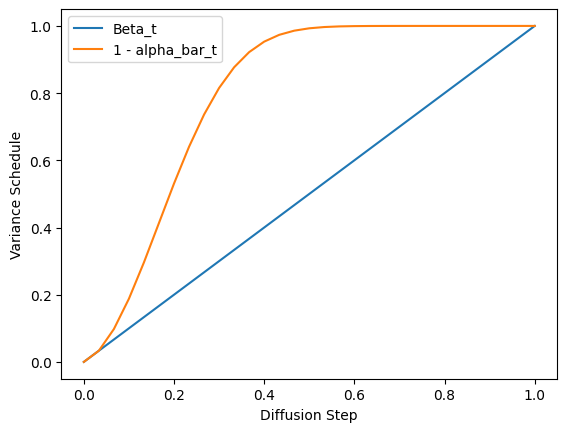

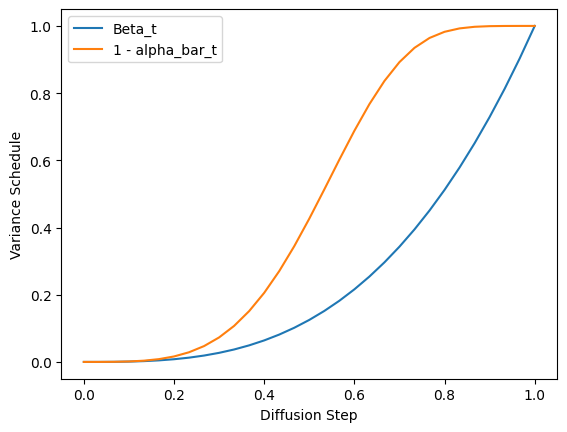

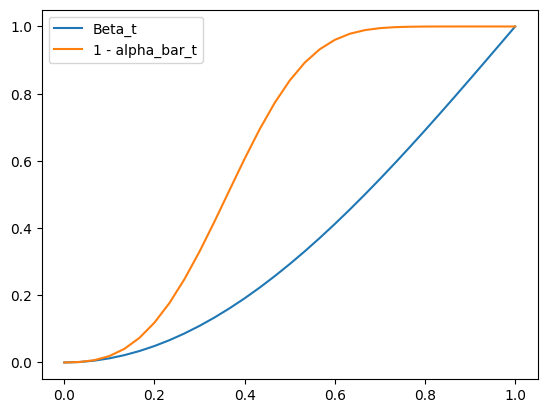

In [2]:
import torch
import math
import matplotlib.pyplot as plt

def compute_alpha_bar(list_of_betas, timestep):
    final_alpha = 1
    for b in list_of_betas:
        final_alpha *= (1 - b)
    
    return final_alpha

T = 30 #used for the x axis

x_axis = [elem / T for elem in range(T + 1)]

beta_linear = []
alpha_bar_linear = []


for t in x_axis:
    beta_linear.append(t)
    alpha_bar_linear.append(1 - compute_alpha_bar(beta_linear, t))


# beta_linear = [elem / T for elem in range(T)]

plt.plot(x_axis, beta_linear)
plt.plot(x_axis, alpha_bar_linear)


plt.xlabel("Diffusion Step")
plt.ylabel("Variance Schedule")

plt.legend(['Beta_t', '1 - alpha_bar_t']) 



beta_polynomial = []
alpha_bar_polynomial = []

for t in x_axis:
    beta_polynomial.append(t ** 3)
    alpha_bar_polynomial.append(1 - compute_alpha_bar(beta_polynomial, t))

plt.figure()

plt.plot(x_axis, beta_polynomial)
plt.plot(x_axis, alpha_bar_polynomial)


plt.legend(['Beta_t', '1 - alpha_bar_t']) 


plt.xlabel("Diffusion Step")
plt.ylabel("Variance Schedule")

beta_cosine = []
alpha_bar_cosine = []

for t in x_axis:
    beta_cosine.append(1 - math.cos(math.pi/2 * t))
    alpha_bar_cosine.append(1 - compute_alpha_bar(beta_cosine, t))

plt.figure()

plt.plot(x_axis, beta_cosine)
plt.plot(x_axis, alpha_bar_cosine)


plt.legend(['Beta_t', '1 - alpha_bar_t']) 

Based on the observations, [Nichol and Dhariwal, 2021](https://arxiv.org/pdf/2102.09672) proposed to construct a different noise schedule in terms of $\bar{\alpha_t}$:
$$\bar{\alpha_t}= \frac{f(t)}{f(0)}, f(t) = \cos(\frac{t/T+s}{1+s} \cdot \frac{\pi}{2})^2$$

For this schedule, generate plots with y-axis being the value of $\beta_t$ and $1-\bar{\alpha_t}$ and x-axis being the diffusion step $t/T$, and use $s=0.008$ and $T=30$. How does this schedule differ from the previous two, and why might it lead to improved performance in the trained diffusion models?

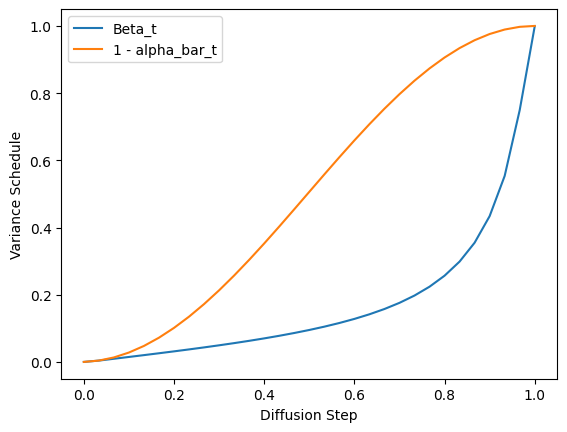

In [3]:
s = 0.008


def f(t):
    return math.cos(((t / T) + s) / (1 + s) * math.pi / 2) ** 2


alpha_bar_cosine_nd = [f(t) / f(0) for t in range(T + 1)]
beta_cosine_nd = [0.0]
for t in range(1, T + 1):
    beta_t = 1 - alpha_bar_cosine_nd[t] / alpha_bar_cosine_nd[t - 1]
    beta_cosine_nd.append(min(beta_t, 0.999))

plt.figure()
plt.plot(x_axis, beta_cosine_nd)
plt.plot(x_axis, [1 - a for a in alpha_bar_cosine_nd])
plt.legend(['Beta_t', '1 - alpha_bar_t'])
plt.xlabel('Diffusion Step')
plt.ylabel('Variance Schedule')
plt.show()


**Schedule Discussion**

Compared with the linear and polynomial schedules, the Nichol-Dhariwal cosine schedule changes the cumulative noise level more smoothly. It avoids corrupting the data too aggressively at early steps, keeps useful signal around for more timesteps, and also avoids an abrupt collapse near the end of the chain. That gives the denoiser a better spread of training examples across easy, medium, and hard noise levels, which usually leads to more stable optimization and better final samples.


# Submission Guideline for Part 2

Please include your answer to all problems, including formulas, proofs, and the figures generated in each problem, excluding code. You are required to submit the (single) pdf and all (four) notebooks (one for each problem) with your code and running outputs. Do not include code in the pdf file. 

Specifically, for Problem 1 in this notebook, the pdf should contain:
- Formulas and proofs for problem 1.1 and 1.2
- 4 figures, one for each beta schedule for problem 1.3
- Answers to the 2 short answer questions about different beta schedules in problem 1.3

---

# Problem notebook: `part2_diffusion_p2.ipynb`  
*(tag: `p2` — autograder uses cell metadata `x_pset_part`)*


# Acknowledgement

Parts of this pset were inspired by
* Berkeley CS294-158, taught by Pieter Abbeel, Wilson Yan, Kevin Frans, and Philipp Wu;
* MIT 6.S184/6.S975, taught by Peter Holderrieth and Ezra Erives;
* The [blog post](https://lilianweng.github.io/posts/2021-07-11-diffusion-models/) about diffusion models by Lilian Weng.




# Submission Guideline for Part 2

Please include your answer to all problems, including formulas, proofs, and the figures generated in each problem, excluding code. You are required to submit the (single) pdf and all (four) notebooks (one for each problem) with your code and running outputs. Do not include code in the pdf file. 

Specifically, for Problem 2 in this notebook, the pdf should contain:
- The generated figures `results/p2_train_plot.png` and `results/p2_toy_samples.png`

# Problem 2: Training Diffusion Models on a Toy Dataset
In this problem, we will write the code for training and sampling from a diffusion model on a 2D toy dataset. This part requires GPUs--you can use Google Colab for GPU access. To work on this notebook in Google Colab, copy the `pset-5` directory to your Google Drive and open this notebook. Then, start working on a GPU machine with `Runtime -> Change runtime type -> T4 GPU`.

## Data Generation and Visualization

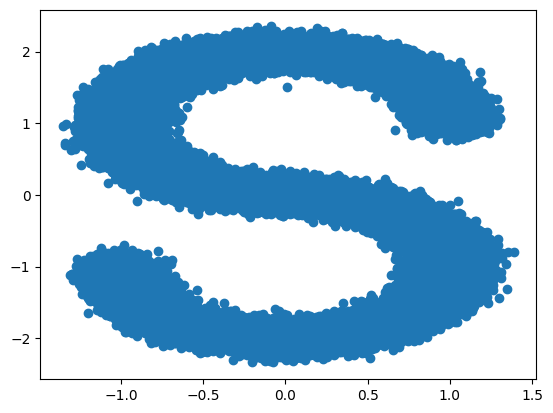

In [4]:
from sklearn.datasets import make_s_curve
import matplotlib.pyplot as plt

def toy_2d_data(n=100000):
    x, _ = make_s_curve(n, noise=0.1)
    x = x[:, [0, 2]]
    return x.astype('float32')

def visualize_toy_2d_dataset():
    data = toy_2d_data()
    plt.figure()
    plt.scatter(data[:, 0], data[:, 1])
    plt.show()

visualize_toy_2d_dataset()

## Training and Sampling of Diffusion Models

For code simplicity, we will train a continuous-time variant of the diffusion prompt. In practice training objectives and code between discrete-time and continuous-time diffusion models are similar.

Given a data element $x$ and neural net $f_\theta(x, t)$, implement the following diffusion training steps:

0. Construct a class `Diffusion`
1. Sample the diffusion timestep: $t \sim \text{Uniform}(0, 1)$
2. Compute the noise-strength following a cosine schedule: $\alpha_t = \cos\left(\frac{\pi}{2}t\right), \sigma_t = \sin\left(\frac{\pi}{2}t\right)$
3. Sample noise $\epsilon \sim N(0,I)$ (same shape as $x$) and cmpute noised $x_t = \alpha_t x + \sigma_t \epsilon$
4. Estimate $\hat{\epsilon} = f_\theta(x_t, t)$
5. Optimize the loss $L = \lVert \epsilon - \hat{\epsilon} \rVert_2^2$. Here, it suffices to just take the mean over all dimensions.

Note that for the case of continuous-time diffusion, the forward process is $x_{0\to1}$ and reverse process is $x_{1\to0}$

Use an MLP for $f_\theta$ to optimize the loss. You may find the following details helpful.
* Normalize the data using mean and std computed from the train dataset
* Train 100 epochs, batch size 1024, Adam with LR 1e-3 (100 warmup steps, cosine decay to 0)
* MLP with 4 hidden layers and hidden size 64
* Condition on t by concatenating it with input x (i.e. 2D x + 1D t = 3D cat(x, t))
* Training 100 epochs takes about 2 minutes on the Google Colab T4 GPU.


To sample, implement the standard DDPM sampler. You may find the equation from the [DDIM paper](https://arxiv.org/pdf/2010.02502.pdf) helpful, rewritten and re-formatted here for convenience.
$$x_{t-1} = \alpha_{t-1}\left(\frac{x_t - \sigma_t\hat{\epsilon}}{\alpha_t}\right) + \sqrt{\sigma_{t-1}^2 - \eta_t^2}\hat{\epsilon} + \eta_t\epsilon_t$$
where $\epsilon_t \sim N(0, I)$ is random Gaussian noise. For DDPM, let
$$\eta_t = \sigma_{t-1}/\sigma_t\sqrt{1 - \alpha_t^2/\alpha_{t-1}^2}$$
*Note*: As a sanity check, when $\eta_t$ follows the DDPM setting as shown above, the resulted coefficient of $x_t$ and $\hat{\epsilon}$ should be the same as $A'$ and $B'$ you derived in Problem 1.2 (6) where $\alpha_t$ here corresponds to $\bar{\alpha_t}$ in Problem 1.

To run the reverse process, start from $x_1 \sim N(0, I)$. Then perform `num_steps` DDPM updates (a hyperparameter), pseudocode below.
```
ts = linspace(1 - 1e-4, 1e-4, num_steps + 1)
x = sample_normal
for i in range(num_steps):
    t = ts[i]
    tm1 = ts[i + 1]
    eps_hat = model(x, t)
    x = DDPM_UPDATE(x, eps_hat, t, tm1)
return x
```
*Note*: 
* If you encounter NaNs, you may need to clip $\sigma_{t-1}^2 - \eta_t^2$ to 0 if it goes negative, as machine precision issues can make it a very small negative number (e.g. -1e-12) if its too close to 0
* For debugging, you can start with trying small number of epochs. To debug your training code, you can check whether the training and testing losses decrease properly. To debug your sampling code, you can check whether the generated distribution is close to the S-shape target distribution with large `num_steps`.
* To check your answer, the final text loss is roughly around 0.4.

In [5]:
import torch
import torch.nn as nn
import math
import numpy as np

class Diffusion:
    def __init__(self, model, data_shape):
        """
        model: neural network to estimate eps_hat (MLP in this problem)
        data_shape: size of the input data, (2,) in this case
        """
        self.model = model
        self.data_shape = data_shape

    def loss(self, x):
        """
        x: the input data (without adding noise) from the dataloader
        Return:
            The loss (as a scalar averaged over all data in the batch)
        """
        batch_size = x.shape[0]
        t = torch.rand(batch_size, device=x.device)
        alpha_t = torch.cos(t * math.pi / 2)[:, None]
        sigma_t = torch.sin(t * math.pi / 2)[:, None]

        eps = torch.randn_like(x)
        x_t = alpha_t * x + sigma_t * eps
        eps_hat = self.model(x_t, t)
        return ((eps - eps_hat) ** 2).mean()

    @torch.no_grad()
    def sample(self, n, num_steps):
        """
        n: number of samples to generate
        num_steps: number of steps in the diffusion sampling
        Return:
            The generated sample. Tensor with shape (n, *self.data_shape)
        """
        device = next(self.model.parameters()).device
        self.model.eval()

        ts = torch.linspace(1 - 1e-4, 1e-4, num_steps + 1, device=device)
        x = torch.randn((n, *self.data_shape), device=device)

        for i in range(num_steps):
            t = ts[i]
            tm1 = ts[i + 1]
            t_batch = torch.full((n,), t, device=device)

            alpha_t = torch.cos(t * math.pi / 2)
            sigma_t = torch.sin(t * math.pi / 2)
            alpha_tm1 = torch.cos(tm1 * math.pi / 2)
            sigma_tm1 = torch.sin(tm1 * math.pi / 2)

            eps_hat = self.model(x, t_batch)
            eta_t = sigma_tm1 / sigma_t * torch.sqrt(
                torch.clamp(1 - (alpha_t ** 2) / (alpha_tm1 ** 2), min=0.0)
            )
            coeff_eps = torch.sqrt(torch.clamp(sigma_tm1 ** 2 - eta_t ** 2, min=0.0))
            noise = torch.randn_like(x)

            x0_hat = (x - sigma_t * eps_hat) / alpha_t
            x = alpha_tm1 * x0_hat + coeff_eps * eps_hat + eta_t * noise

        return x

    def __getattr__(self, name):
        if name in ['train', 'eval', 'parameters', 'state_dict', 'load_state_dict']:
            return getattr(self.model, name)
        return self.__getattribute__(name)


class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_hidden_layers, timestep_dim=1):
        super().__init__()
        self.timestep_dim = timestep_dim
        prev_dim = input_dim + timestep_dim
        net = []
        dims = [hidden_dim] * n_hidden_layers + [input_dim]
        for i, dim in enumerate(dims):
            net.append(nn.Linear(prev_dim, dim))
            if i < len(dims) - 1:
                net.append(nn.ReLU())
            prev_dim = dim
        self.net = nn.Sequential(*net)

    def forward(self, x, t):
        x = torch.cat([x, t[:, None]], dim=1)
        return self.net(x)


In [6]:
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm

def train(model, train_loader, optimizer, scheduler):
    """
    model: model to train, the Diffusion class in this case.
    train_loader: dataloader for the train_data after normalization
    optimizer: use torch.optim.Adam
    scheduler: use optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=lambda step: get_lr(step, total_steps, warmup_steps, use_cos_decay)
    )
    Return:
        Tensor with train loss of each batch
    """
    model.train()
    device = next(model.parameters()).device
    train_losses = []

    for (x,) in tqdm(train_loader, leave=False):
        x = x.to(device)
        optimizer.zero_grad()
        loss = model.loss(x)
        loss.backward()
        optimizer.step()
        scheduler.step()
        train_losses.append(loss.item())

    return train_losses

@torch.no_grad()
def eval_loss(model, data_loader):
    """
    model: model to train, the Diffusion class in this case.
    data_loader: dataloader for the test_data after normalization
    Return:
        Scalar with the average test loss of each batch
    """
    model.eval()
    device = next(model.parameters()).device
    losses = []

    for (x,) in data_loader:
        x = x.to(device)
        losses.append(model.loss(x).item())

    return float(np.mean(losses))

def get_lr(step, total_steps, warmup_steps, use_cos_decay):
    """
    Function that returns the learning rate for the specific step, used in defining the scheduler:
        scheduler = optim.lr_scheduler.LambdaLR(
            optimizer,
            lr_lambda=lambda step: get_lr(step, total_steps, warmup_steps, use_cos_decay)
        )
    """
    if warmup_steps > 0 and step < warmup_steps:
        return (step + 1) / warmup_steps

    if use_cos_decay:
        decay_steps = max(total_steps - warmup_steps, 1)
        progress = min(max(step - warmup_steps, 0) / decay_steps, 1.0)
        return 0.5 * (1 + np.cos(np.pi * progress))

    return 1.0

def train_epochs(model, train_loader, test_loader, train_args):
    """
    model: model to train, the Diffusion class in this case.
    train_loader: dataloader for the train_data after normalization
    test_loader: dataloader for the test_data after normalization
    Return:
        Two np.array for all the train losses and test losses at each step
    """
    epochs, lr = train_args['epochs'], train_args['lr']
    warmup_steps = train_args.get('warmup', 0)
    use_cos_decay = train_args.get('use_cos_decay', False)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    total_steps = epochs * len(train_loader)
    scheduler = optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=lambda step: get_lr(step, total_steps, warmup_steps, use_cos_decay),
    )

    train_losses = []
    test_losses = [eval_loss(model, test_loader)]

    for _ in tqdm(range(epochs)):
        train_losses.extend(train(model, train_loader, optimizer, scheduler))
        test_losses.append(eval_loss(model, test_loader))

    return np.array(train_losses), np.array(test_losses)


In [7]:
import torch.utils.data as data

def toy_diffusion(train_data, test_data):
    """
    train_data: A (100000, 2) numpy array of 2D points
    test_data: A (10000, 2) numpy array of 2D points

    Returns
    - a (# of training iterations,) numpy array of train losses evaluated every minibatch
    - a (# of num_epochs + 1,) numpy array of test losses evaluated at the start of training and the end of every epoch
    - a numpy array of size (9, 2000, 2) of samples drawn from your model.
      Draw 2000 samples for each of 9 different number of diffusion sampling steps
      of evenly logarithmically spaced integers 1 to 512
      hint: np.power(2, np.linspace(0, 9, 9)).astype(int)
    """
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    train_mean = train_data.mean(axis=0, keepdims=True)
    train_std = train_data.std(axis=0, keepdims=True)

    train_data_norm = (train_data - train_mean) / train_std
    test_data_norm = (test_data - train_mean) / train_std

    train_dataset = data.TensorDataset(torch.from_numpy(train_data_norm))
    test_dataset = data.TensorDataset(torch.from_numpy(test_data_norm))
    train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

    model = MLP(input_dim=2, hidden_dim=64, n_hidden_layers=4)
    model = Diffusion(model.to(device), (2,))

    train_args = {
        'epochs': 100,
        'lr': 1e-3,
        'warmup': 100,
        'use_cos_decay': True,
    }
    train_losses, test_losses = train_epochs(model, train_loader, test_loader, train_args)

    num_steps = np.power(2, np.linspace(0, 9, 9)).astype(int)
    samples = []
    for steps in num_steps:
        x_gen = model.sample(2000, int(steps)).cpu().numpy()
        x_gen = x_gen * train_std + train_mean
        samples.append(x_gen)

    return train_losses, test_losses, np.stack(samples, axis=0)


In [8]:
import os
from os.path import exists, dirname


def check_losses(test_name, losses_array, loss_threshold):
    """Sanity-check training: mean of the last few test losses should fall below the threshold.

    For toy 2D training, final test NLL should end up around ~0.4; use e.g. loss_threshold=0.45.
    """
    average_loss_last5 = np.mean(losses_array[-5:])
    if average_loss_last5 >= loss_threshold:
        print(test_name, ": Your function isn't optimized well")
        return False
    else:
        print(test_name, ": Your function works!")
    return True


def savefig(fname: str, show_figure: bool = True) -> None:
    if not exists(dirname(fname)):
        os.makedirs(dirname(fname))
    plt.tight_layout()
    plt.savefig(fname)
    if show_figure:
        plt.show()


def save_training_plot(
    train_losses: np.ndarray, test_losses: np.ndarray, title: str, fname: str
) -> None:
    plt.figure()
    n_epochs = len(test_losses) - 1
    x_train = np.linspace(0, n_epochs, len(train_losses))
    x_test = np.arange(n_epochs + 1)

    plt.plot(x_train, train_losses, label="train loss")
    plt.plot(x_test, test_losses, label="test loss")
    plt.legend()
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("NLL")
    savefig(fname)

In [9]:
def save_multi_scatter_2d(data: np.ndarray) -> None:
    fig, axs = plt.subplots(3, 3, figsize=(10, 10))
    num_steps = np.power(2, np.linspace(0, 9, 9)).astype(int)
    for i in range(3):
        for j in range(3):
            axs[i, j].scatter(data[i * 3 + j, :, 0], data[i * 3 + j, :, 1])
            axs[i, j].set_title(f'Steps = {num_steps[i * 3 + j]}')
    savefig("results/p2_toy_samples.png")


def toy_save_results(fn):
    train_data = toy_2d_data(n=100000)
    test_data = toy_2d_data(n=10000)
    train_losses, test_losses, samples = fn(train_data, test_data)

    print(f"Final Test Loss: {test_losses[-1]:.4f}")
    # Expect final test NLL ~0.4; mean of last 5 epochs should stay below ~0.45
    check_losses("train_epochs (toy 2D)", test_losses, loss_threshold=0.45)

    save_training_plot(
        train_losses,
        test_losses,
        f"P2 Train Plot",
        f"results/p2_train_plot.png"
    )

    save_multi_scatter_2d(samples)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/98 [00:00<?, ?it/s]

  1%|          | 1/98 [00:00<00:44,  2.16it/s]

  5%|▌         | 5/98 [00:00<00:09,  9.81it/s]

 11%|█         | 11/98 [00:00<00:04, 21.10it/s]

...

 61%|██████    | 60/98 [00:00<00:00, 165.22it/s]

 84%|████████▎ | 82/98 [00:00<00:00, 179.47it/s]

100%|██████████| 100/100 [01:42<00:00,  1.52it/s]

100%|██████████| 100/100 [01:42<00:00,  1.02s/it]

Final Test Loss: 0.4091
train_epochs (toy 2D) : Your function works!


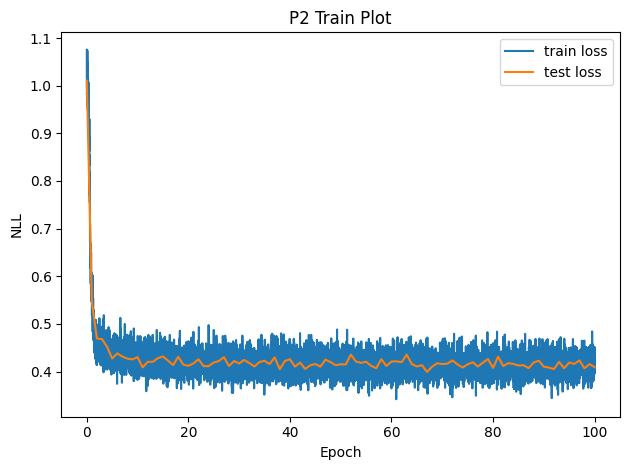

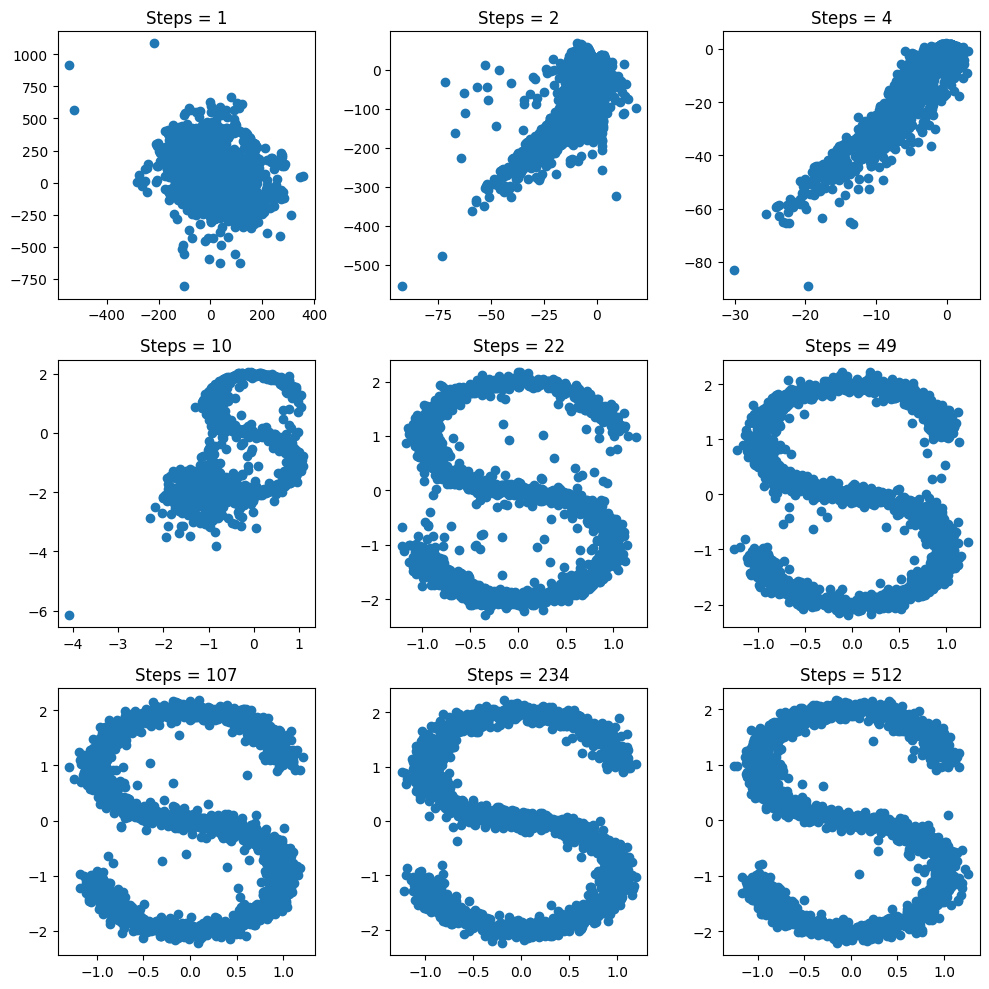

In [10]:
toy_save_results(toy_diffusion)

# Submission Guideline for Part 2

Please include your answer to all problems, including formulas, proofs, and the figures generated in each problem, excluding code. You are required to submit the (single) pdf and all (four) notebooks (one for each problem) with your code and running outputs. Do not include code in the pdf file. 

Specifically, for Problem 2 in this notebook, the pdf should contain:
- The generated figures `results/p2_train_plot.png` and `results/p2_toy_samples.png`

---

# Problem notebook: `part2_diffusion_p3.ipynb`  
*(tag: `p3` — autograder uses cell metadata `x_pset_part`)*


# Acknowledgement

Parts of this pset were inspired by
* Berkeley CS294-158, taught by Pieter Abbeel, Wilson Yan, Kevin Frans, and Philipp Wu;
* MIT 6.S184/6.S975, taught by Peter Holderrieth and Ezra Erives;
* The [blog post](https://lilianweng.github.io/posts/2021-07-11-diffusion-models/) about diffusion models by Lilian Weng.




# Submission Guideline for Part 2

Please include your answer to all problems, including formulas, proofs, and the figures generated in each problem, excluding code. You are required to submit the (single) pdf and all (four) notebooks (one for each problem) with your code and running outputs. Do not include code in the pdf file.

Specifically, for Problem 3 in this notebook, the pdf should contain:
- The generated figures `results/mnist_train_plot.png` and `results/image_w{w}.png` (w=0.0, 0.5, 1.0, 2.0, 4.0)
- Answer to the short answer question about the U-Net architecture
- Answer to the short answer question about different CFG weight $w$ in problem 3.2

# Problem 3: MNIST and Conditional Generation
In this problem, we will write the code for conditional generation on the MNIST dataset. This part requires GPUs--you can use Google Colab for GPU access. To work on this notebook in Google Colab, copy the `pset-5` directory to your Google Drive and open this notebook. Then, start working on a GPU machine with `Runtime -> Change runtime type -> T4 GPU`.

## MNIST Dataset


In [11]:
from torchvision import transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader

tf = transforms.Compose([transforms.ToTensor()])
train_dataset = MNIST("./data", train=True, download=True, transform=tf)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_dataset = MNIST("./data", train=False, download=True, transform=tf)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

  0%|          | 0.00/9.91M [00:00<?, ?B/s]

 35%|███▌      | 3.47M/9.91M [00:00<00:00, 34.7MB/s]

100%|██████████| 9.91M/9.91M [00:00<00:00, 73.5MB/s]

  0%|          | 0.00/28.9k [00:00<?, ?B/s]

100%|██████████| 28.9k/28.9k [00:00<00:00, 2.66MB/s]

  0%|          | 0.00/1.65M [00:00<?, ?B/s]

100%|██████████| 1.65M/1.65M [00:00<00:00, 23.5MB/s]

  0%|          | 0.00/4.54k [00:00<?, ?B/s]

100%|██████████| 4.54k/4.54k [00:00<00:00, 8.03MB/s]

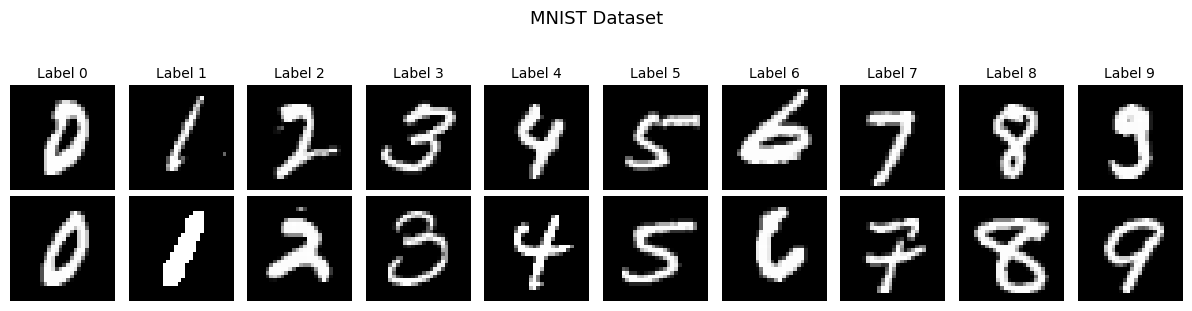

In [12]:
# visualize data by label
import matplotlib.pyplot as plt

images_by_label = {i: [] for i in range(10)}

for images, labels in train_loader:
    for img, label in zip(images, labels):
        if len(images_by_label[label.item()]) < 2:
            images_by_label[label.item()].append(img.squeeze(0))
        if all(len(images) == 2 for images in images_by_label.values()):
            break
    if all(len(images) == 2 for images in images_by_label.values()):
        break

# Plot the images
fig, axes = plt.subplots(2, 10, figsize=(12, 3))
fig.suptitle("MNIST Dataset", fontsize=13, y=1.05)

for label, imgs in images_by_label.items():
    for i, img in enumerate(imgs):
        ax = axes[i, label]
        ax.imshow(img.numpy(), cmap="gray")
        ax.axis("off")
        if i == 0:
            ax.set_title(f"Label {label}", fontsize=10)

plt.tight_layout(pad=1.0)
plt.show()

## 3.1 U-Net: Architecture for Image Data
In the toy dataset, we choose MLP as the architecture of the denoising diffusion models, and use concatenation as the way to incorporate the time embedding. Although this works fine for simple synthetic distributions, it no longer suffices for complex high-dimensional distributions like images. In this problem, we will introduce the U-Net architecture specifically designed for images.

Specifically, we apply [classifier-free guidance](https://arxiv.org/pdf/2207.12598) (CFG) for conditional generation of MNIST digits, conditioned on the digit label. CFG is a widely used method during diffusion model sampling to push samples towards more accurately aligning with the conditioning information (e.g. class, text caption).

When applying CFG, the label embedding, together with the time embedding, is added to each hidden layer of the U-Net. A diagram of the U-Net we'll be using is shown below (we change BatchNorm to GroupNorm for better performance).

In [13]:
from typing import List
import torch.nn as nn
import math
import torch
import os
from tqdm import tqdm
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt
import numpy as np
import torch.optim as optim
from matplotlib.pyplot import savefig

In [14]:
class FourierEncoder(nn.Module):
    """
    Based on https://github.com/lucidrains/denoising-diffusion-pytorch/blob/main/denoising_diffusion_pytorch/karras_unet.py#L183
    """
    def __init__(self, dim: int):
        super().__init__()
        assert dim % 2 == 0
        self.half_dim = dim // 2
        self.weights = nn.Parameter(torch.randn(1, self.half_dim))

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
        - t: (bs, 1, 1, 1)
        Returns:
        - embeddings: (bs, dim)
        """
        t = t.view(-1, 1) # (bs, 1)
        freqs = t * self.weights * 2 * math.pi # (bs, half_dim)
        sin_embed = torch.sin(freqs) # (bs, half_dim)
        cos_embed = torch.cos(freqs) # (bs, half_dim)
        return torch.cat([sin_embed, cos_embed], dim=-1) * math.sqrt(2) # (bs, dim)

class ResidualLayer(nn.Module):
    def __init__(self, channels: int, time_embed_dim: int, y_embed_dim: int):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=8, num_channels=channels),
            nn.SiLU(),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=8, num_channels=channels),
            nn.SiLU(),
        )
        # Converts (bs, time_embed_dim) -> (bs, channels)
        self.time_adapter = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_embed_dim, channels)
        )
        # Converts (bs, y_embed_dim) -> (bs, channels)
        self.y_adapter = nn.Sequential(
            nn.SiLU(),
            nn.Linear(y_embed_dim, channels)
        )

    def forward(self, x: torch.Tensor, t_embed: torch.Tensor, y_embed: torch.Tensor) -> torch.Tensor:
        """
        Args:
        - x: (bs, c, h, w)
        - t_embed: (bs, t_embed_dim)
        - y_embed: (bs, y_embed_dim)
        """
        res = x.clone() # (bs, c, h, w)

        # Initial conv block
        x = self.block1(x) # (bs, c, h, w)

        # Add time embedding
        t_embed = self.time_adapter(t_embed).unsqueeze(-1).unsqueeze(-1) # (bs, c, 1, 1)
        x = x + t_embed

        # Add y embedding (conditional embedding)
        y_embed = self.y_adapter(y_embed).unsqueeze(-1).unsqueeze(-1) # (bs, c, 1, 1)
        x = x + y_embed

        # Second conv block
        x = self.block2(x) # (bs, c, h, w)

        # Add back residual
        x = x + res # (bs, c, h, w)

        return x

class Encoder(nn.Module):
    def __init__(self, channels_in: int, channels_out: int, num_residual_layers: int, t_embed_dim: int, y_embed_dim: int):
        super().__init__()
        self.res_blocks = nn.ModuleList([
            ResidualLayer(channels_in, t_embed_dim, y_embed_dim) for _ in range(num_residual_layers)
        ])
        self.downsample = nn.Conv2d(channels_in, channels_out, kernel_size=3, stride=2, padding=1)

    def forward(self, x: torch.Tensor, t_embed: torch.Tensor, y_embed: torch.Tensor) -> torch.Tensor:
        """
        Args:
        - x: (bs, c_in, h, w)
        - t_embed: (bs, t_embed_dim)
        - y_embed: (bs, y_embed_dim)
        """
        # Pass through residual blocks: (bs, c_in, h, w) -> (bs, c_in, h, w)
        for block in self.res_blocks:
            x = block(x, t_embed, y_embed)

        # Downsample: (bs, c_in, h, w) -> (bs, c_out, h // 2, w // 2)
        x = self.downsample(x)

        return x

class Midcoder(nn.Module):
    def __init__(self, channels: int, num_residual_layers: int, t_embed_dim: int, y_embed_dim: int):
        super().__init__()
        self.res_blocks = nn.ModuleList([
            ResidualLayer(channels, t_embed_dim, y_embed_dim) for _ in range(num_residual_layers)
        ])

    def forward(self, x: torch.Tensor, t_embed: torch.Tensor, y_embed: torch.Tensor) -> torch.Tensor:
        """
        Args:
        - x: (bs, c, h, w)
        - t_embed: (bs, t_embed_dim)
        - y_embed: (bs, y_embed_dim)
        """
        # Pass through residual blocks: (bs, c, h, w) -> (bs, c, h, w)
        for block in self.res_blocks:
            x = block(x, t_embed, y_embed)

        return x

class Decoder(nn.Module):
    def __init__(self, channels_in: int, channels_out: int, num_residual_layers: int, t_embed_dim: int, y_embed_dim: int):
        super().__init__()
        self.upsample = nn.Sequential(nn.Upsample(scale_factor=2, mode='bilinear'), nn.Conv2d(channels_in, channels_out, kernel_size=3, padding=1))
        self.res_blocks = nn.ModuleList([
            ResidualLayer(channels_out, t_embed_dim, y_embed_dim) for _ in range(num_residual_layers)
        ])

    def forward(self, x: torch.Tensor, t_embed: torch.Tensor, y_embed: torch.Tensor) -> torch.Tensor:
        """
        Args:
        - x: (bs, c, h, w)
        - t_embed: (bs, t_embed_dim)
        - y_embed: (bs, y_embed_dim)
        """
        # Upsample: (bs, c_in, h, w) -> (bs, c_out, 2 * h, 2 * w)
        x = self.upsample(x)

        # Pass through residual blocks: (bs, c_out, h, w) -> (bs, c_out, 2 * h, 2 * w)
        for block in self.res_blocks:
            x = block(x, t_embed, y_embed)

        return x

class MNISTUNet(nn.Module):
    def __init__(self, channels: List[int], num_residual_layers: int, t_embed_dim: int, y_embed_dim: int):
        super().__init__()
        # Initial convolution: (bs, 1, 32, 32) -> (bs, c_0, 32, 32)
        self.init_conv = nn.Sequential(
            nn.Conv2d(1, channels[0], kernel_size=3, padding=1),
            # nn.BatchNorm2d(channels[0]),
            nn.GroupNorm(num_groups=8, num_channels=channels[0]),
            nn.SiLU()
        )

        # Initialize time embedder
        self.time_embedder = FourierEncoder(t_embed_dim)

        # Initialize y embedder
        self.y_embedder = nn.Embedding(num_embeddings = 11, embedding_dim = y_embed_dim)

        # Encoders, Midcoders, and Decoders
        encoders = []
        decoders = []
        for (curr_c, next_c) in zip(channels[:-1], channels[1:]):
            encoders.append(Encoder(curr_c, next_c, num_residual_layers, t_embed_dim, y_embed_dim))
            decoders.append(Decoder(next_c, curr_c, num_residual_layers, t_embed_dim, y_embed_dim))
        self.encoders = nn.ModuleList(encoders)
        self.decoders = nn.ModuleList(reversed(decoders))

        self.midcoder1 = Midcoder(channels[-1], num_residual_layers, t_embed_dim, y_embed_dim)
        self.midcoder2 = Midcoder(channels[-1], num_residual_layers, t_embed_dim, y_embed_dim)

        # Final convolution
        self.final_conv = nn.Sequential(
            nn.GroupNorm(num_groups=8, num_channels=channels[0]),
            nn.SiLU(),
            nn.Conv2d(channels[0], 1, kernel_size=3, padding=1)
        )

    def forward(self, x: torch.Tensor, t: torch.Tensor, y: torch.Tensor):
        """
        Args:
        - x: (bs, 1, 32, 32)
        - t: (bs, 1, 1, 1)
        - y: (bs,)
        Returns:
        - u_t^theta(x|y): (bs, 1, 32, 32)
        """
        # Embed t and y
        t_embed = self.time_embedder(t) # (bs, time_embed_dim)
        y_embed = self.y_embedder(y) # (bs, y_embed_dim)

        # Initial convolution
        x = self.init_conv(x) # (bs, c_0, 32, 32)

        residuals = []

        # Encoders
        for encoder in self.encoders:
            x = encoder(x, t_embed, y_embed) # (bs, c_i, h, w) -> (bs, c_{i+1}, h // 2, w //2)
            residuals.append(x.clone())

        # Midcoder
        x = self.midcoder1(x, t_embed, y_embed)
        x = self.midcoder2(x, t_embed, y_embed)

        # Decoders
        for decoder in self.decoders:
            res = residuals.pop() # (bs, c_i, h, w)
            x = x + res
            x = decoder(x, t_embed, y_embed) # (bs, c_i, h, w) -> (bs, c_{i-1}, 2 * h, 2 * w)

        # Final convolution
        x = self.final_conv(x) # (bs, 1, 32, 32)

        return x

**Please explain each components of the architecture above** (each one of `FourierEncoder`, `ResidualLayer`, `Encoder`, `Decoder`, or `Midcoder`) in your own words, (1) their role in the U-Net, (2) their inputs and outputs, and (3) a brief description of how the inputs turn into outputs.

**Architecture Explanation**

- `FourierEncoder`: maps the scalar timestep into a higher-dimensional periodic embedding so the network can condition every layer on where the sample is in the diffusion process. Input is a batch of timesteps; output is a batch of sinusoidal feature vectors.
- `ResidualLayer`: refines a feature map while injecting both the time embedding and the label embedding. It takes an image feature tensor plus two embedding vectors, runs two conv-norm-activation blocks, adds the broadcasted embeddings, and then adds the residual connection back.
- `Encoder`: keeps the same channel count through several residual layers and then downsamples to a coarser spatial resolution with more channels. Its role is to compress the image into increasingly semantic features.
- `Midcoder`: processes the bottleneck representation at the lowest resolution without changing spatial size. It lets the network mix global information before decoding.
- `Decoder`: upsamples the coarse representation back to a finer resolution and refines it with residual layers conditioned on time and label. Its role is to reconstruct detailed spatial structure while using the information gathered by the encoder path.


## 3.2 Classifier-Free Guidance

Implement CFG requires a small modification to the diffusion training and sampling code.

*During training*, we randomly drop out the class label with a certain probability `drop_prob=0.1`, i.e. we use a dummy embedding to replace the digit label embedding.

*During sampling*, given a digit label, instead of using $\hat{\epsilon} = f_\theta(x_t, t, y)$ to sample, use:
$$\hat{\epsilon} = f_\theta(x_t, t, \varnothing) + w(f_\theta(x_t, t, y) - f_\theta(x_t, t, \varnothing))$$
where $w$ is a sampling hyperparameter that controls the strength of CFG. $\varnothing$ indicates the unconditional model with the class label dropped out, which is supported by the dummy embedding during training. Note that $w = 1$ recovers standard sampling.

Please modify the code you wrote for Problem 2 for unconditional generation to adapt for the CFG setting. You can change the model architecture from MLP to UNet. Specifically, given a data element $x$ and U-Net $f_\theta(x, t)$, implement the following diffusion training steps similar as what we did in Problem 2, while using a different noise schedule (in step 2):
0. Construct a class `MNISTDiffusion`
1. Sample the diffusion timestep: $t \sim \text{Uniform}(0, 1)$
2. Compute the noise-strength following a linear schedule: $\alpha_t = 1-t, \sigma_t = \sqrt{1-(1-t)^2}$
3. Sample noise $\epsilon \sim N(0,I)$ (same shape as $x$) and cmpute noised $x_t = \alpha_t x + \sigma_t \epsilon$
4. Estimate $\hat{\epsilon} = f_\theta(x_t, t)$
5. Optimize the loss $L = \lVert \epsilon - \hat{\epsilon} \rVert_2^2$. Here, it suffices to just take the mean over all dimensions.

*Note*: you can reuse your code from Problem 2 for functions `train`, `eval_loss`, `get_lr`, and `train_epochs`.

*Hyperparameter details*
* UNet with hidden_dims as [64, 128] and 1 blocks_per_dim
* Train 10 epochs, batch size 128, Adam with LR 1e-3 (0 warmup steps, and `use_cosine_decay=True`)
* Training 10 epochs takes about 7 minutes on the Google Colab T4 GPU.

After training, please generate 4 images for each of the 10 digit labels using guidance strength $w$ of 0.0, 0.5, 1.0, 2.0, 4.0 respectively, and save the images as 4x10 grid of images (each column is a digit). You are required to submit the images for each guidance strength along with the training loss curve. **Comparing the results with different $w$, what can you say about its impact to the generation performance?**

*Hint*: To check your answer, the final test loss is below 0.02.

In [15]:
class MNISTDiffusion:
    def __init__(self, model, data_shape, device, n_classes, drop_prob=0.1):
        """
        model: neural network to estimate eps_hat (U-Net in this problem)
        data_shape: size of the input data, (1, 28, 28) in this case
        device: cuda
        n_classes: number of classes for conditional generation, set to 10 in this problem
        drop_prob: probability of dropping the condition in CFG training
        """
        self.model = model.to(device)
        self.data_shape = data_shape
        self.device = device
        self.drop_prob = drop_prob
        self.n_classes = n_classes
    
    def loss(self, x, y):
        """
        x: the input data (without adding noise) from the dataloader
        y: the class label
        Return:
            The loss (as a scalar averaged over all data in the batch)
        """
        batch_size = x.shape[0]
        t = torch.rand(batch_size, 1, 1, 1, device=self.device)
        alpha_t = 1 - t
        sigma_t = torch.sqrt(torch.clamp(1 - alpha_t ** 2, min=0.0))

        eps = torch.randn_like(x)
        x_t = alpha_t * x + sigma_t * eps

        y_cond = y.clone()
        drop_mask = torch.rand(batch_size, device=self.device) < self.drop_prob
        y_cond[drop_mask] = self.n_classes

        eps_hat = self.model(x_t, t, y_cond)
        return ((eps - eps_hat) ** 2).mean()

    @torch.no_grad()
    def sample(self, n, num_steps, guide_w=0.0):
        """
        n: number of samples to generate (you should generate int(n/n_classes) samples for each class and thus n samples in total)
        num_steps: number of steps in the diffusion sampling
        guide_w: the CFG weight
        Return:
            The generated sample. Tensor with shape (n, *self.data_shape)
        """
        assert n % self.n_classes == 0, 'n must be divisible by n_classes'
        self.model.eval()

        samples_per_class = n // self.n_classes
        y = torch.arange(self.n_classes, device=self.device).repeat(samples_per_class)
        y_uncond = torch.full((n,), self.n_classes, device=self.device, dtype=torch.long)

        ts = torch.linspace(1 - 1e-4, 1e-4, num_steps + 1, device=self.device)
        x = torch.randn((n, *self.data_shape), device=self.device)

        for i in range(num_steps):
            t = ts[i]
            tm1 = ts[i + 1]
            t_batch = torch.full((n, 1, 1, 1), t, device=self.device)

            alpha_t = 1 - t
            sigma_t = torch.sqrt(torch.clamp(1 - alpha_t ** 2, min=0.0))
            alpha_tm1 = 1 - tm1
            sigma_tm1 = torch.sqrt(torch.clamp(1 - alpha_tm1 ** 2, min=0.0))

            eps_cond = self.model(x, t_batch, y)
            eps_uncond = self.model(x, t_batch, y_uncond)
            eps_hat = eps_uncond + guide_w * (eps_cond - eps_uncond)

            eta_t = sigma_tm1 / sigma_t * torch.sqrt(
                torch.clamp(1 - (alpha_t ** 2) / (alpha_tm1 ** 2), min=0.0)
            )
            coeff_eps = torch.sqrt(torch.clamp(sigma_tm1 ** 2 - eta_t ** 2, min=0.0))
            noise = torch.randn_like(x)

            x0_hat = (x - sigma_t * eps_hat) / alpha_t
            x = alpha_tm1 * x0_hat + coeff_eps * eps_hat + eta_t * noise

        return x.clamp(0.0, 1.0)

    def __getattr__(self, name):
        if name in ['train', 'eval', 'parameters', 'state_dict', 'load_state_dict']:
            return getattr(self.model, name)
        return self.__getattribute__(name)


# You can reuse your implementations in part 2 problem 2 for the following four functions

def train(model, train_loader, optimizer, scheduler):
    """
    model: model to train, the MNISTDiffusion class in this case.
    train_loader: train_loader
    optimizer: use torch.optim.Adam
    scheduler: use optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=lambda step: get_lr(step, total_steps, warmup_steps, use_cos_decay)
    )
    Return:
        Tensor with train loss of each batch
    """
    model.train()
    train_losses = []

    for x, y in tqdm(train_loader, leave=False):
        x = x.to(model.device)
        y = y.to(model.device)
        optimizer.zero_grad()
        loss = model.loss(x, y)
        loss.backward()
        optimizer.step()
        scheduler.step()
        train_losses.append(loss.item())

    return train_losses


@torch.no_grad()
def eval_loss(model, data_loader):
    """
    model: model to train, the MNISTDiffusion class in this case.
    data_loader: test_loader
    Return:
        Scalar with the average test loss of each batch
    """
    model.eval()
    losses = []

    for x, y in data_loader:
        x = x.to(model.device)
        y = y.to(model.device)
        losses.append(model.loss(x, y).item())

    return float(np.mean(losses))


def get_lr(step, total_steps, warmup_steps, use_cos_decay):
    """
    Function that returns the learning rate for the specific step, used in defining the scheduler:
        scheduler = optim.lr_scheduler.LambdaLR(
            optimizer,
            lr_lambda=lambda step: get_lr(step, total_steps, warmup_steps, use_cos_decay)
        )
    """
    if warmup_steps > 0 and step < warmup_steps:
        return (step + 1) / warmup_steps

    if use_cos_decay:
        decay_steps = max(total_steps - warmup_steps, 1)
        progress = min(max(step - warmup_steps, 0) / decay_steps, 1.0)
        return 0.5 * (1 + np.cos(np.pi * progress))

    return 1.0


def train_epochs(model, train_loader, test_loader, train_args):
    """
    model: model to train, the MNISTDiffusion class in this case.
    train_loader: train_loader
    test_loader: test_loader
    Return:
        Two np.array for all the train losses and test losses at each step
    """
    epochs, lr = train_args['epochs'], train_args['lr']
    warmup_steps = train_args.get('warmup', 0)
    use_cos_decay = train_args.get('use_cos_decay', False)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    total_steps = epochs * len(train_loader)
    scheduler = optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=lambda step: get_lr(step, total_steps, warmup_steps, use_cos_decay),
    )

    train_losses = []
    test_losses = [eval_loss(model, test_loader)]

    for _ in tqdm(range(epochs)):
        train_losses.extend(train(model, train_loader, optimizer, scheduler))
        test_losses.append(eval_loss(model, test_loader))

    return np.array(train_losses), np.array(test_losses)


In [16]:
def mnist_diffusion(train_loader, test_loader):
    """
    train_loader: MNIST training data
    test_loader: MNIST test data

    Returns
    - a (# of training iterations,) numpy array of train losses evaluated every minibatch
    - a (# of num_epochs + 1,) numpy array of test losses evaluated at the start of training and the end of every epoch

    Generate 4 images for each of the 10 digits in `./results/`, using guidance strengths of 0.0, 0.5, 1.0, 2.0, 4.0.
    Save the images as `./results/image_w{w}.png` as 4x10 grid of images (each column is a digit)
    hint: x_gen is the output from model.sample, use the following to generate and save grids
            grid = make_grid(x_gen*-1 + 1, nrow=10)
            save_image(grid, save_dir + f"image_w{w}.png")
    """

    n_classes = 10
    save_dir = './results/'
    os.makedirs(save_dir, exist_ok=True)
    ws_test = [0.0, 0.5, 1.0, 2.0, 4.0] # strength of generative guidance
    num_steps = 512
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    model = MNISTUNet(
        channels = [64, 128],
        num_residual_layers = 1,
        t_embed_dim = 64,
        y_embed_dim = 64,
    )
    model = MNISTDiffusion(model, (1, 28, 28), device=device, n_classes=n_classes, drop_prob=0.1)

    train_args = {
        'epochs': 10,
        'lr': 1e-3,
        'warmup': 0,
        'use_cos_decay': True,
    }
    train_losses, test_losses = train_epochs(model, train_loader, test_loader, train_args)

    for w in ws_test:
        x_gen = model.sample(40, num_steps=num_steps, guide_w=w).cpu()
        grid = make_grid(x_gen * -1 + 1, nrow=10)
        save_image(grid, save_dir + f'image_w{w}.png')

    return train_losses, test_losses


In [17]:
def check_losses(test_name, losses_array, loss_threshold):
    """Sanity-check training: mean of the last few test losses should fall below the threshold.

    For MNIST diffusion, final test NLL should end below ~0.02.
    """
    average_loss_last5 = np.mean(losses_array[-5:])
    if average_loss_last5 >= loss_threshold:
        print(test_name, ": Your function isn't optimized well")
        return False
    else:
        print(test_name, ": Your function works!")
    return True


def save_training_plot(
    train_losses: np.ndarray, test_losses: np.ndarray, title: str, fname: str
) -> None:
    plt.figure()
    n_epochs = len(test_losses) - 1
    x_train = np.linspace(0, n_epochs, len(train_losses))
    x_test = np.arange(n_epochs + 1)

    plt.plot(x_train, train_losses, label="train loss")
    plt.plot(x_test, test_losses, label="test loss")
    plt.legend()
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("NLL")
    savefig(fname)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/469 [00:00<?, ?it/s]

  0%|          | 1/469 [00:00<04:20,  1.80it/s]

  1%|▏         | 6/469 [00:00<00:41, 11.12it/s]

  2%|▏         | 11/469 [00:00<00:24, 18.84it/s]

...

 98%|█████████▊| 461/469 [00:11<00:00, 40.52it/s]

 99%|█████████▉| 466/469 [00:11<00:00, 42.24it/s]

100%|██████████| 10/10 [02:31<00:00, 13.61s/it]

100%|██████████| 10/10 [02:31<00:00, 15.14s/it]

Final Test Loss: 0.0172
train_epochs (MNIST) : Your function works!


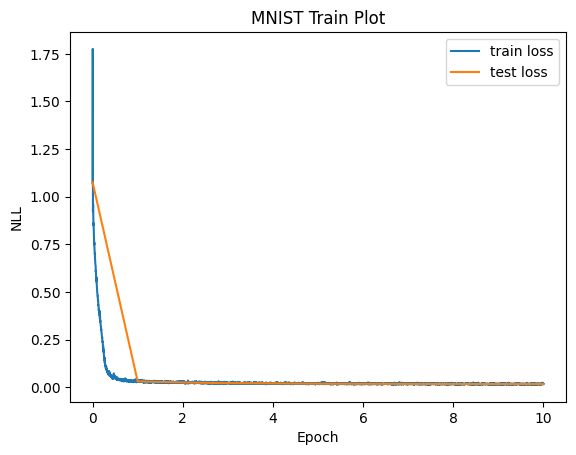

In [18]:
train_losses, test_losses = mnist_diffusion(train_loader, test_loader)
print(f"Final Test Loss: {test_losses[-1]:.4f}")
# Expect final test NLL below ~0.02; mean of last 5 epochs must stay under threshold
check_losses("train_epochs (MNIST)", test_losses, loss_threshold=0.02)

save_training_plot(
    train_losses,
    test_losses,
    f"MNIST Train Plot",
    f"results/mnist_train_plot.png"
)

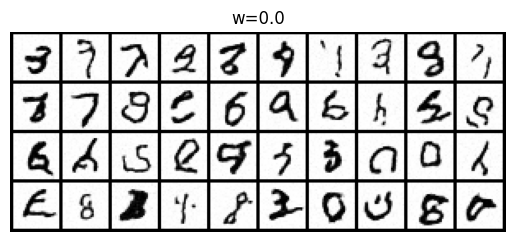

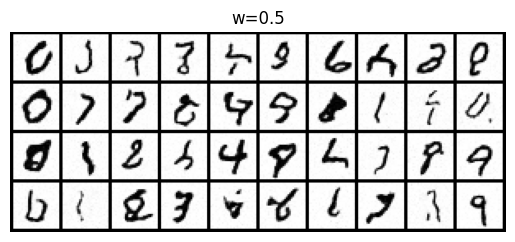

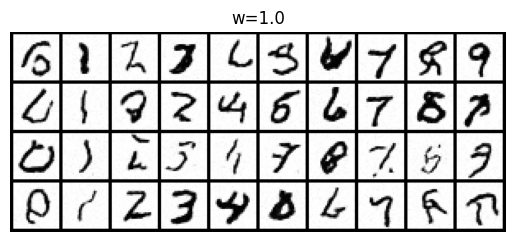

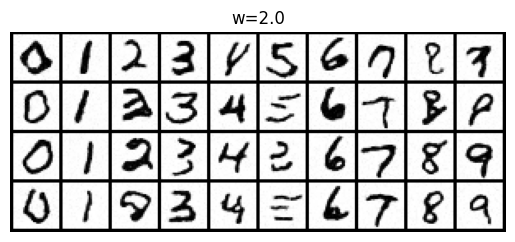

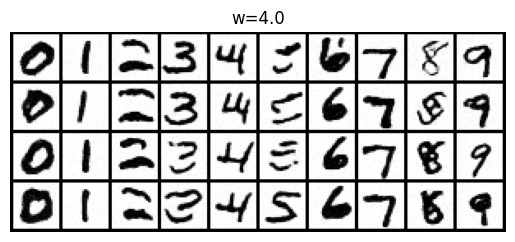

In [19]:
import matplotlib.image as mpimg

ws_test = [0.0, 0.5, 1.0, 2.0, 4.0]
for w in ws_test:
  img_path = f'results/image_w{w}.png'
  img = mpimg.imread(img_path)
  plt.title(f'w={w}')
  plt.imshow(img)
  plt.axis('off')
  plt.show()

**CFG Weight Discussion**

Small guidance weights keep the samples diverse but the class identity can be weaker. Moderate guidance usually gives the best tradeoff: digits become sharper and better aligned with the requested label without collapsing too much. Very large guidance often over-constrains the reverse process, which can reduce diversity and introduce artifacts or unnatural-looking digits.


# Submission Guideline for Part 2

Please include your answer to all problems, including formulas, proofs, and the figures generated in each problem, excluding code. You are required to submit the (single) pdf and all (four) notebooks (one for each problem) with your code and running outputs. Do not include code in the pdf file.

Specifically, for Problem 3 in this notebook, the pdf should contain:
- The generated figures `results/mnist_train_plot.png` and `results/image_w{w}.png` (w=0.0, 0.5, 1.0, 2.0, 4.0)
- Answer to the short answer question about the U-Net architecture
- Answer to the short answer question about different CFG weight $w$ in problem 3.2

---

# Problem notebook: `part2_diffusion_p4.ipynb`  
*(tag: `p4` — autograder uses cell metadata `x_pset_part`)*


# Acknowledgement

Parts of this pset were inspired by
* Berkeley CS294-158, taught by Pieter Abbeel, Wilson Yan, Kevin Frans, and Philipp Wu;
* MIT 6.S184/6.S975, taught by Peter Holderrieth and Ezra Erives;
* The [blog post](https://lilianweng.github.io/posts/2021-07-11-diffusion-models/) about diffusion models by Lilian Weng.




# Submission Guideline for Part 2

Please include your answer to all problems, including formulas, proofs, and the figures generated in each problem, excluding code. You are required to submit the (single) pdf and all (four) notebooks (one for each problem) with your code and running outputs. Do not include code in the pdf file. 

Specifically, for Problem 4 in this notebook, the pdf should contain:
- The generated figures `results/sampling_comparison.png`
- Answer to the short answer question about different samplers and number of steps

# Problem 4: Sampling based on Pretrained Models
In this problem, you will implement two ODE based sampling algorithms for diffusion models:

* Euler sampler
* Euler sampler with Heun correction

You'll apply these samplers to a [pretrained diffusion model](https://huggingface.co/google/ddpm-cifar10-32) on CIFAR-10 and compare their results. Note that in this problem (unlike in Problem 2 and 3), we use the stochastic equation perspective of diffusion models, as introduced in [Song *et al*., 2021](https://arxiv.org/pdf/2011.13456).

This part requires GPUs--you can use Google Colab for GPU access. To work on this notebook in Google Colab, copy the `pset-5` directory to your Google Drive and open this notebook. Then, start working on a GPU machine with `Runtime -> Change runtime type -> T4 GPU`.

## Pretrained Model on CIFAR-10

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from diffusers import DDPMPipeline
from tqdm.auto import tqdm
from diffusers import DDIMScheduler

# Load a pretrained DDPM model on CIFAR-10
model_id = "google/ddpm-cifar10-32"
device = "cuda" if torch.cuda.is_available() else "cpu"
torch_dtype = torch.float16 if device == "cuda" else torch.float32

pipeline = DDPMPipeline.from_pretrained(model_id, torch_dtype=torch_dtype)
pipeline = pipeline.to(device)

# Extract the necessary components
unet = pipeline.unet
# The original scheduler is for SDE sampling. Initialize another scheduler for ODE sampling.
ode_scheduler = DDIMScheduler.from_config(pipeline.scheduler.config)

# Helper function to visualize results
def show_images(images, title=None, figsize=(10, 10)):
    plt.figure(figsize=figsize)
    if title:
        plt.suptitle(title)

    for i, img in enumerate(images):
        plt.subplot(4, 4, i + 1)
        if isinstance(img, torch.Tensor):
            img = img.detach().cpu().numpy()
        if img.shape[0] == 3:  # If the image has a channel dimension first
            img = np.transpose(img, (1, 2, 0))
        plt.imshow(img)
        plt.axis('off')

    plt.tight_layout()
    plt.show()


Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /data/scratch/zhangbr/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory /data/scratch/zhangbr/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80.


Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


## Euler Sampler with Heun Correction
The diffusion sampling process involves solving the ordinary differential equation (ODE):

$$\frac{dx}{dt} = f(x, t)$$

where $f(x, t)$ is the drift coefficient derived from the score function.

The Euler method with Heun correction is a second-order method:
* **Euler Step (Predictor)**:
    $$\hat{x}_{t-\Delta t} = x_t - \Delta t \cdot f(x_t, t)$$

* **Heun Correction (Corrector)**:
    $$x_{t-\Delta t} = x_t - \frac{\Delta t}{2} \cdot \big[f(x_t, t) + f(\hat{x}_{t-\Delta t}, t-\Delta t)\big]$$

You need to use the [`diffusers`](https://huggingface.co/docs/diffusers/en/index) package for certain classes and functions. The drift function $f(x_t, t)$ can be obtained by:
```
model_output = model(sample, t).sample
```

Complete the function `euler_heun_sampler` and evaluate it using the given comparison code. What can you conclude based on the generated images using different samplers and number of steps?

In [2]:
@torch.inference_mode()
def euler_heun_sampler(model, scheduler, num_inference_steps=50, num_images=8,
                       device="cuda", use_heun=False):
    """
    Implement the Euler sampler with Heun correction for diffusion models

    Args:
        model: The U-Net model that predicts noise residuals
        scheduler: Diffusion scheduler with step, add_noise, and other utilities
        num_inference_steps: Number of denoising steps
        num_images: Number of images to generate
        device: Device to run the model on
        use_heun: Whether to use Heun correction (default: False)

    Returns:
        A batch of generated images on CPU
    """
    device = device if torch.cuda.is_available() or device != 'cuda' else 'cpu'
    model = model.to(device)
    model.eval()
    model_dtype = next(model.parameters()).dtype

    scheduler.set_timesteps(num_inference_steps, device=device)
    sample = torch.randn((num_images, 3, 32, 32), device=device, dtype=model_dtype)
    sample = sample * scheduler.init_noise_sigma

    timesteps = scheduler.timesteps
    for i, timestep in enumerate(tqdm(timesteps)):
        model_input = scheduler.scale_model_input(sample, timestep)
        model_output = model(model_input, timestep).sample
        euler_prev = scheduler.step(model_output, timestep, sample, eta=0.0).prev_sample

        if use_heun and i < len(timesteps) - 1:
            next_timestep = timesteps[i + 1]
            next_input = scheduler.scale_model_input(euler_prev, next_timestep)
            next_model_output = model(next_input, next_timestep).sample
            corrected_model_output = 0.5 * (model_output + next_model_output)
            sample = scheduler.step(corrected_model_output, timestep, sample, eta=0.0).prev_sample
        else:
            sample = euler_prev

    return (sample.float() / 2 + 0.5).clamp(0, 1).cpu()


In [3]:
def compare_samplers(model, ode_scheduler, num_inference_steps_list=[10, 20, 50],
                     num_images=8, device="cuda"):
    """
    Compare different sampling methods with varying inference steps
    """
    results = {}

    for steps in num_inference_steps_list:
        print(f"\nGenerating samples with {steps} inference steps:")

        # Set random seed for reproducibility
        torch.manual_seed(42)
        print("\nRunning Euler sampler:")
        euler_samples = euler_heun_sampler(
            model=model,
            scheduler=ode_scheduler,
            num_inference_steps=steps,
            num_images=num_images,
            device=device,
            use_heun=False
        )
        results[f"euler_{steps}"] = euler_samples
        if device == "cuda" and torch.cuda.is_available():
            torch.cuda.empty_cache()

        # Reset random seed for fair comparison
        torch.manual_seed(42)
        print("\nRunning Euler-Heun sampler:")
        euler_heun_samples = euler_heun_sampler(
            model=model,
            scheduler=ode_scheduler,
            num_inference_steps=steps,
            num_images=num_images,
            device=device,
            use_heun=True
        )
        results[f"euler_heun_{steps}"] = euler_heun_samples
        if device == "cuda" and torch.cuda.is_available():
            torch.cuda.empty_cache()

    return results



Generating samples with 10 inference steps:

Running Euler sampler:


  0%|          | 0/10 [00:00<?, ?it/s]


Running Euler-Heun sampler:


  0%|          | 0/10 [00:00<?, ?it/s]


Generating samples with 50 inference steps:

Running Euler sampler:


...

  0%|          | 0/50 [00:00<?, ?it/s]


Generating samples with 250 inference steps:

Running Euler sampler:


  0%|          | 0/250 [00:00<?, ?it/s]


Running Euler-Heun sampler:


  0%|          | 0/250 [00:00<?, ?it/s]

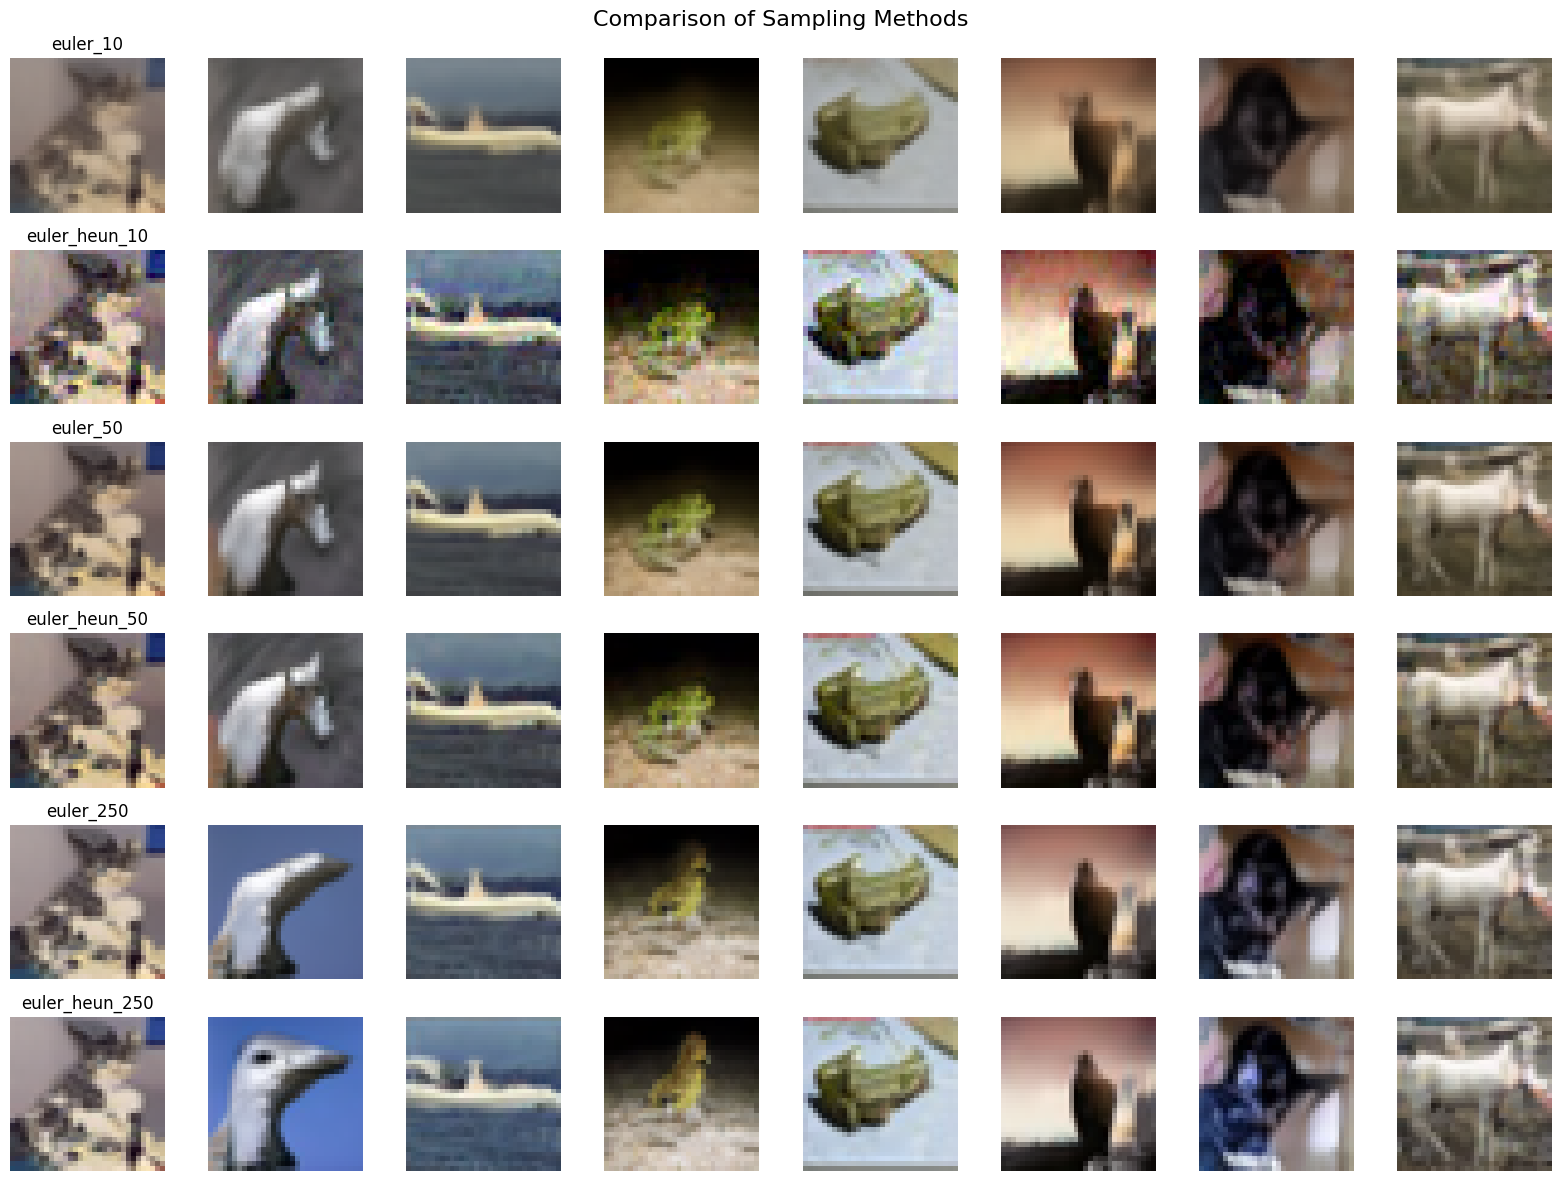

In [4]:
results = compare_samplers(unet, ode_scheduler, num_inference_steps_list=[10, 50, 250], num_images=8)
rows = len(results.keys())
fig, axs = plt.subplots(rows, 8, figsize=(16, rows * 2))
fig.suptitle("Comparison of Sampling Methods", fontsize=16)

for i, (method, samples) in enumerate(results.items()):
    for j in range(8):
        img = samples[j].detach().cpu().permute(1, 2, 0).numpy()
        axs[i, j].imshow(img)
        axs[i, j].set_title(method if j == 0 else "")
        axs[i, j].axis('off')

plt.tight_layout()
plt.savefig('results/sampling_comparison.png', dpi=300)
plt.show()


**Conclusion**

At a fixed step budget, more denoising steps usually improve sample fidelity because the ODE is integrated more accurately. Heun correction typically helps most when the step count is small: it reduces the local truncation error of plain Euler, so the samples are usually cleaner and more stable at 10 or 50 steps. As the number of steps becomes large, the gap narrows because both samplers are already close to the continuous trajectory.


# Submission Guideline for Part 2

Please include your answer to all problems, including formulas, proofs, and the figures generated in each problem, excluding code. You are required to submit the (single) pdf and all (four) notebooks (one for each problem) with your code and running outputs. Do not include code in the pdf file. 

Specifically, for Problem 4 in this notebook, the pdf should contain:
- The generated figures `results/sampling_comparison.png`
- Answer to the short answer question about different samplers and number of steps